In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# PARAMETER RANDOM
NPM = 19102
np.random.seed(NPM)

# LOAD DATA
makan = pd.read_csv("makanan_new.csv")

# SANITASI DATA
req_cols = {"makanan", "harga", "kenyang", "rasa", "sehat", "bosan"}
makan = makan.dropna(subset=req_cols).copy()
for c in ["kenyang", "rasa", "sehat", "bosan"]:
    makan[c] = makan[c].clip(0, 1)
makan["harga"] = pd.to_numeric(makan["harga"], errors="coerce")
makan = makan[makan["harga"] > 0].reset_index(drop=True)

# PARAMETER SIMULASI
budget = 1_000_000
SAMPLE_NUM, HARI, MAKAN_PER_HARI = 500, 31, 2
wkenyang_base, wrasa_base, wsehat_base, wbosan_base = 0.8, 0.7, 0.9, 0.2

sampleid = np.arange(SAMPLE_NUM)
skor = np.zeros(SAMPLE_NUM)
sisa = np.zeros(SAMPLE_NUM)
sehat = np.zeros(SAMPLE_NUM)
resp_pilih = np.zeros((SAMPLE_NUM, HARI * MAKAN_PER_HARI), int)

SISA_MIN, SISA_MAX = 150e3, 300e3
bin_sisa = np.arange(SISA_MIN, SISA_MAX, 1000, dtype=int)
resp_sehat = np.zeros((SAMPLE_NUM, len(bin_sisa)))

# SIMULASI
for n in range(SAMPLE_NUM):
    bgt, s_kum, s_sehat = budget, 0.0, 0.0
    for i in range(HARI):
        # MAKAN PAGI
        pilihan = np.random.randint(0, len(makan))
        w_kenyang = np.random.normal(wkenyang_base, 0.2)
        w_rasa = np.random.normal(wrasa_base, 0.2)
        w_sehat = np.random.normal(wsehat_base, 0.4)
        w_bosan = np.random.normal(wbosan_base, 0.2)
        s_kum += (
            w_kenyang * makan["kenyang"].iloc[pilihan]
            + w_rasa * makan["rasa"].iloc[pilihan]
            + w_sehat * makan["sehat"].iloc[pilihan]
            - w_bosan * makan["bosan"].iloc[pilihan]
        )
        s_sehat += makan["sehat"].iloc[pilihan] - 0.5
        bgt -= makan["harga"].iloc[pilihan]
        resp_pilih[n, 2 * i] = pilihan

        # MAKAN MALAM
        pilihan = np.random.randint(0, len(makan))
        w_kenyang = np.random.normal(wkenyang_base, 0.2)
        w_rasa = np.random.normal(wrasa_base, 0.2)
        w_sehat = np.random.normal(wsehat_base + 0.2, 0.4)
        w_bosan = np.random.normal(wbosan_base * 2, 0.2)
        s_kum += (
            w_kenyang * makan["kenyang"].iloc[pilihan]
            + w_rasa * makan["rasa"].iloc[pilihan]
            + w_sehat * makan["sehat"].iloc[pilihan]
            - w_bosan * makan["bosan"].iloc[pilihan]
        )
        s_sehat += makan["sehat"].iloc[pilihan] - 0.5
        bgt -= makan["harga"].iloc[pilihan]
        resp_pilih[n, 2 * i + 1] = pilihan

    sisa[n], skor[n], sehat[n] = bgt, s_kum, s_sehat
    if np.isfinite(bgt):
        idx = int(np.floor((bgt - SISA_MIN) / 1000))
        if 0 <= idx < resp_sehat.shape[1]:
            resp_sehat[n, idx] = s_sehat

# TUGAS
# (1) cari pola makan mana saja yang menghasilkan nilai kumulatif kesehatan (resp_sehat) positif 
print("\nNo.1 :")
sampel_sehat = np.where(sehat > 0)[0]
print(f"(1) Jumlah sampel sehat positif : {len(sampel_sehat)}")
if len(sampel_sehat) > 0:
    pilihan_sehat = resp_pilih[sampel_sehat].ravel()
    frek = np.bincount(pilihan_sehat, minlength=len(makan))
    topk = 10
    idx_top = np.argsort(-frek)[:topk]
    print(f"    Top {topk} menu pada sampel sehat:")
    for i, idx in enumerate(idx_top, 1):
        if frek[idx] > 0:
            print(f"    {i:2d}. {makan['makanan'].iloc[idx]:20s} | frekuensi : {frek[idx]}")

# (2) cari titik-titik dengan sisa uang bulanan positif dari (1)
print("\nNo.2 :")
sampel_sehat_sisa = np.where((sehat > 0) & (sisa > 0))[0]
print(f"(2) Jumlah sampel sehat & sisa positif : {len(sampel_sehat_sisa)}")
if len(sampel_sehat_sisa) > 0:
    top_idx = np.argsort(-sisa[sampel_sehat_sisa])[:5]
    for r, j in enumerate(top_idx, 1):
        idx = sampel_sehat_sisa[j]
        print(
            f"    {r}. Sampel #{idx} | Sisa = Rp{int(sisa[idx]):,} | Sehat = {sehat[idx]:.3f} | Skor = {skor[idx]:.3f}"
        )

# (3) cari titik dengan skor skumulatif terbesar (skor) di mana nilai kumulatif kesehatannya positif
print("\nNo.3 :")
if len(sampel_sehat) > 0:
    skor_masked = np.where(sehat > 0, skor, -np.inf)
    best_idx = int(np.argmax(skor_masked))
    print(
        f"(3) Sampel #{best_idx} skor max | Skor = {skor[best_idx]:.3f} | Sehat = {sehat[best_idx]:.3f} | Sisa = Rp{int(sisa[best_idx]):,}"
    )
else:
    best_idx = None
    print("(3) Tidak ada sampel sehat positif")

# (4) tampilkan jadwal makanan sesuai pilihan (resp_pilih)
print("\nNo.4 :")
def tampilkan_jadwal(n_idx):
    if n_idx is None:
        print("\nTidak ada jadwal.")
        return
    print(f"\n=== JADWAL MAKAN (Sampel #{n_idx}) ===")
    total_biaya = 0
    for h in range(HARI):
        pagi, malam = resp_pilih[n_idx, 2 * h], resp_pilih[n_idx, 2 * h + 1]
        nama_pagi, harga_pagi = makan["makanan"].iloc[pagi], makan["harga"].iloc[pagi]
        nama_malam, harga_malam = makan["makanan"].iloc[malam], makan["harga"].iloc[malam]
        total_biaya += harga_pagi + harga_malam
        print(
            f"Hari {h+1:02d} - Pagi : {nama_pagi:20s} (Rp{int(harga_pagi):,}) | "
            f"Malam : {nama_malam:20s} (Rp{int(harga_malam):,})"
        )
    print(f"Total biaya 31 hari : Rp{int(total_biaya):,}")
    print(f"Sisa uang : Rp{int(sisa[n_idx]):,}")
    print(f"Skor kumulatif : {skor[n_idx]:.3f} | Skor sehat : {sehat[n_idx]:.3f}")

tampilkan_jadwal(best_idx)


No.1 :
(1) Jumlah sampel sehat positif : 496
    Top 10 menu pada sampel sehat:
     1. capcay               | frekuensi : 1106
     2. nasikuning           | frekuensi : 1089
     3. tahutek              | frekuensi : 1082
     4. ayamgeprek           | frekuensi : 1072
     5. sotoayam             | frekuensi : 1063
     6. lontongbalap         | frekuensi : 1061
     7. nasigorengkambing    | frekuensi : 1052
     8. tahucampur           | frekuensi : 1052
     9. rawon                | frekuensi : 1050
    10. nasitelur            | frekuensi : 1050

No.2 :
(2) Jumlah sampel sehat & sisa positif : 496
    1. Sampel #401 | Sisa = Rp166,000 | Sehat = 3.100 | Skor = 91.893
    2. Sampel #41 | Sisa = Rp165,000 | Sehat = 0.300 | Skor = 91.457
    3. Sampel #206 | Sisa = Rp164,000 | Sehat = 2.500 | Skor = 88.432
    4. Sampel #184 | Sisa = Rp164,000 | Sehat = 4.100 | Skor = 99.392
    5. Sampel #341 | Sisa = Rp163,000 | Sehat = 1.500 | Skor = 97.014

No.3 :
(3) Sampel #380 skor max | Sk

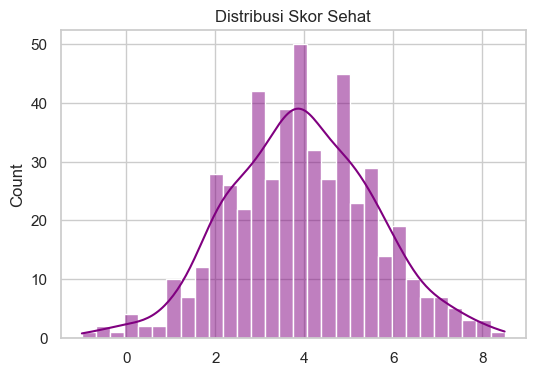

In [26]:
# VISUALISASI
# HISTOGRAM
plt.figure(figsize=(6, 4))
sns.histplot(sehat, bins=30, kde=True, color="purple")
plt.title("Distribusi Skor Sehat")
plt.show()

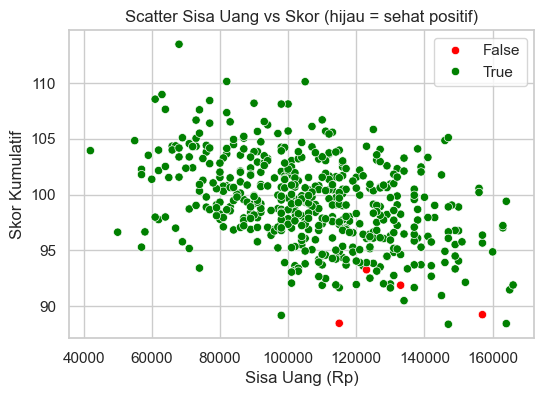

In [27]:
# VISUALISASI
# SCATTER PLOT
plt.figure(figsize=(6, 4))
sns.scatterplot(x=sisa, y=skor, hue=(sehat > 0), palette={True: "green", False: "red"})
plt.title("Scatter Sisa Uang vs Skor (hijau = sehat positif)")
plt.xlabel("Sisa Uang (Rp)")
plt.ylabel("Skor Kumulatif")
plt.show()

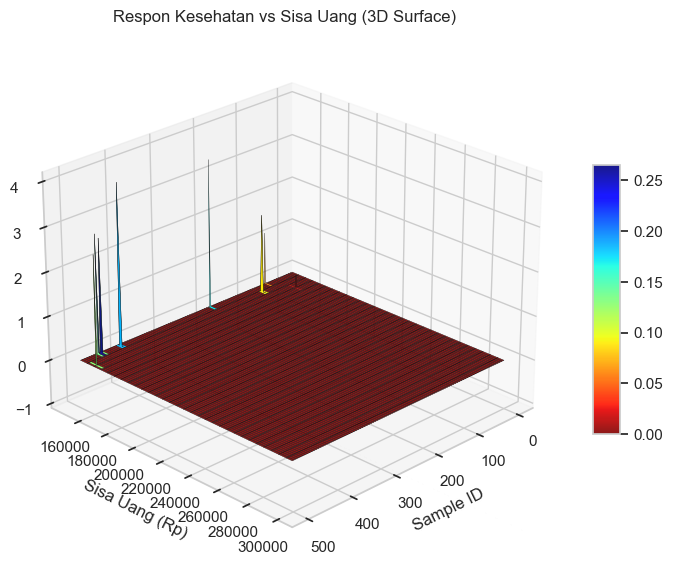

In [31]:
# VISUALISASI
# 3D SURFACE PLOT
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection="3d")

Y, X = np.meshgrid(bin_sisa, sampleid)
surf = ax.plot_surface(
    X,
    Y,
    resp_sehat,
    cmap="jet_r",
    edgecolor="k",
    linewidth=0.3,
    rstride=5,
    cstride=5,
    alpha=0.9
)

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
ax.set_title("Respon Kesehatan vs Sisa Uang (3D Surface)", fontsize=12)
ax.set_xlabel("Sample ID")
ax.set_ylabel("Sisa Uang (Rp)")
ax.set_zlabel("Skor Kesehatan")
ax.view_init(elev=25, azim=45)
plt.show()